# Build an SRE Incident Response Agent with Claude Managed Agents

## Introduction

When a production alert fires at 3 a.m., someone has to pull the
logs, find the right runbook, trace the misconfiguration, open a PR,
and get it approved. An agent can take that first pass for you and
have a fix waiting for review by the time you're at the keyboard — as
long as it has the right context and a human makes the final call.

[Claude Managed Agents](https://platform.claude.com/docs/en/managed-agents/overview)
gives you the scalable infrastructure, sandboxing, & security pieces to build that with ease. In this
tutorial you'll wire them together:

- A simulated **PagerDuty webhook** triggers your Claude Managed Agent with one API call.
- A **Skill** teaches the agent your team's runbook conventions, so it
  knows where to look.
- The built-in `bash`/`read`/`edit` tools let it investigate logs and
  infrastructure code in a sandbox.
- **Custom tools** let it open a pull request and ask a human to
  approve before merging — your code handles those calls, so you
  decide what "open a PR" actually does.
- The **Anthropic Console** records every step automatically, providing you complete observability.

Everything below runs with only `ANTHROPIC_API_KEY`. PagerDuty,
GitHub, and Datadog are mocked with local fixtures so you can focus on
the Managed Agents pieces; the closing section shows how to swap each
mock for the real service.

### What you'll learn

- Upload a Skill and attach it to a Claude Managed Agent
- Mix the built-in toolset with custom tools your application handles
- Start a session from a webhook payload
- Gate a destructive action behind human approval
- Read the full session trace in the Console

### Prerequisites

Set `ANTHROPIC_API_KEY` in your environment, then install
dependencies:


In [1]:
%pip install -q "anthropic>=0.91.0" python-dotenv

In [2]:
import json
import os
import time
from pathlib import Path

from anthropic import Anthropic
from dotenv import load_dotenv
from utilities import wait_for_idle_status

load_dotenv()
client = Anthropic()
MODEL = os.getenv("COOKBOOK_MODEL", "claude-opus-4-6")
FIXTURE = Path("example_data/sre")

## 1. Upload a runbook skill

A
[**Skill**](https://platform.claude.com/docs/en/managed-agents/skills)
is a small filesystem bundle the platform mounts into the agent's
context with progressive disclosure: the agent sees a one-line
description up front and reads the body only when it's relevant. It's
a good place for team conventions that shouldn't live in the system
prompt.

The sample skill below encodes one rule — *consult the runbook before
touching infrastructure* — the way a real team playbook would. You
upload it once via the Skills API and reference it by ID on every
agent that needs it.


In [3]:
# A real skill is usually a folder on disk (SKILL.md plus any helper
# scripts or reference docs) that you zip and upload. For this tutorial
# the SKILL.md is small enough to keep inline.
RUNBOOK_SKILL = """\
---
name: incident-runbooks
description: How to triage production incidents using the team runbooks.
---

# Incident runbooks

When an alert references a service, locate that service's recent logs
and identify the failure signature (the repeating error class, exit
code, or status pattern).

Consult the team runbooks before proposing any fix. Runbooks are
organised by failure signature — for example `oom.md`, `5xx.md`,
`latency.md`. Each one lists the triage steps for that class of
failure and the configuration that usually needs to change.

Any fix to infrastructure code must be opened as a pull request that
cites the runbook you followed. Do not patch live resources directly.
"""

skill = client.beta.skills.create(
    display_title="incident-runbooks",
    files=[("incident-runbooks/SKILL.md", RUNBOOK_SKILL.encode(), "text/markdown")],
)
print(f"skill: {skill.id} (version {skill.latest_version})")

skill: skill_01WPWHALbtEVBUWG6mHa7Tna (version 1775588716519983)


## 2. Create the agent

The agent's `tools` list combines three kinds of capability:

- [`agent_toolset_20260401`](https://platform.claude.com/docs/en/managed-agents/tools)
  — the built-in `bash`, `read`, `grep`, `edit`, … tools that run
  *inside* the sandbox. The agent uses these to investigate.
- The runbook **skill** from step 1.
- Three **custom tools** — `open_pull_request`, `request_approval`,
  and `merge_pull_request` — that the agent can call but *your
  application* executes. They're how the agent reaches systems
  outside the sandbox, and how you put a human in the loop.

The system prompt is persona and workflow only. The alert itself
arrives as the first user event, so the same agent handles any
incident.


In [4]:
SRE_SYSTEM_PROMPT = """\
You are an on-call SRE agent. Each user message is a PagerDuty alert
payload. Triage it to root cause and ship the minimal safe fix.

The session workspace contains the recent logs, the infrastructure
repo, and the team runbooks for the alerting service. Explore it to
find what you need.

Workflow for every alert:
1. Read the logs and identify the failure signature.
2. Find the root cause in the infrastructure repo, save a copy of the
   original file, edit it in place, then produce a unified diff with
   `diff -u`.
3. open_pull_request(title, body, diff) with the fix.
4. request_approval(summary) and wait for the human's decision.
5. Only if the result is "approved", merge_pull_request(pr_number).
   Otherwise stop and report.

Never call merge_pull_request unless request_approval returned
"approved". Keep the fix minimal — do not refactor unrelated config.
"""

agent = client.beta.agents.create(
    name="cookbook-sre-responder",
    model=MODEL,
    system=SRE_SYSTEM_PROMPT,
    skills=[{"type": "custom", "skill_id": skill.id, "version": skill.latest_version}],
    tools=[
        {
            "type": "agent_toolset_20260401",
            "default_config": {
                "enabled": True,
                "permission_policy": {"type": "always_allow"},
            },
            "configs": [
                {"name": "web_search", "enabled": False},
                {"name": "web_fetch", "enabled": False},
            ],
        },
        {
            "type": "custom",
            "name": "open_pull_request",
            "description": "Open a pull request against the infra repo with the proposed fix.",
            "input_schema": {
                "type": "object",
                "properties": {
                    "title": {"type": "string"},
                    "body": {"type": "string"},
                    "diff": {"type": "string", "description": "Unified diff of the change."},
                },
                "required": ["title", "body", "diff"],
            },
        },
        {
            "type": "custom",
            "name": "request_approval",
            "description": "Ask the on-call human to approve the proposed PR before merging.",
            "input_schema": {
                "type": "object",
                "properties": {
                    "summary": {"type": "string"},
                },
                "required": ["summary"],
            },
        },
        {
            "type": "custom",
            "name": "merge_pull_request",
            "description": "Merge an approved pull request.",
            "input_schema": {
                "type": "object",
                "properties": {
                    "pr_number": {"type": "integer"},
                },
                "required": ["pr_number"],
            },
        },
    ],
)
print(f"agent: {agent.id} v{agent.version}")

agent: agent_011CZpw3Y76Vu4t2j2QEosVa v1


## 3. Create an environment and mount the data

The agent needs three things in its workspace to investigate: the
recent service logs, the infrastructure repo, and the team runbooks.
Upload each via the Files API and list them as `resources` so they're
mounted into every session at the paths the system prompt expects. A
`limited`-networking cloud environment is enough because the agent
only needs its own filesystem.

To keep this notebook runnable with only `ANTHROPIC_API_KEY`, the
infra "repo" is a single manifest with a too-low `memory: 128Mi`
limit. In production you'd replace that upload with a
`github_repository` resource that clones the real repo straight into
the sandbox:

```python
{
    "type": "github_repository",
    "url": "https://github.com/your-org/infra",
    "authorization_token": os.environ["GITHUB_TOKEN"],
    "checkout": {"type": "branch", "name": "main"},
    "mount_path": "infra",
}
```


In [5]:
env = client.beta.environments.create(
    name="cookbook-sre-env",
    config={"type": "cloud", "networking": {"type": "limited"}},
)


def upload(path: Path, mime: str) -> str:
    with path.open("rb") as f:
        return client.beta.files.upload(file=(path.name, f, mime)).id


log_id = upload(FIXTURE / "logs/checkout-svc.log", "text/plain")
manifest_id = upload(FIXTURE / "infra/k8s/checkout-deploy.yaml", "text/yaml")
runbook_id = upload(FIXTURE / "runbooks/oom.md", "text/markdown")

RESOURCES = [
    {"type": "file", "file_id": log_id, "mount_path": "logs/checkout-svc.log"},
    {"type": "file", "file_id": manifest_id, "mount_path": "infra/k8s/checkout-deploy.yaml"},
    {"type": "file", "file_id": runbook_id, "mount_path": "runbooks/oom.md"},
]
print(f"environment: {env.id}")

environment: env_01R6hmJkd6BhpPotXnoC7rqU


## 4. Handle the incident alert

The handler below is the one function you'd deploy — a Flask or
FastAPI route that your alerting system calls when an incident fires.
It creates a session referencing the agent and environment, mounts
the data, and sends the alert JSON as the first `user.message` event.
This example uses a [PagerDuty V3
webhook](https://developer.pagerduty.com/docs/webhooks-overview)
payload, but any pager that can POST JSON works the same way; here
you call the handler directly with the fixture.


In [6]:
def handle_pagerduty_webhook(payload: dict) -> str:
    incident = payload["event"]["data"]
    session = client.beta.sessions.create(
        environment_id=env.id,
        agent={"type": "agent", "id": agent.id, "version": agent.version},
        resources=RESOURCES,
        title=f"[{incident['service']['summary']}] {incident['title']}",
    )
    client.beta.sessions.events.send(
        session.id,
        events=[
            {
                "type": "user.message",
                "content": [{"type": "text", "text": json.dumps(payload, indent=2)}],
            }
        ],
    )
    return session.id


with (FIXTURE / "alert.json").open() as f:
    alert = json.load(f)

session_id = handle_pagerduty_webhook(alert)
print(f"session: {session_id}")

session: sesn_011CZpw3gtC691y7qmaLNmLM


## 5. Service the agent's custom tool calls

This is where the built-in tools and your custom tools come together.
The agent's `read`/`bash`/`edit` calls run on the container and
appear in the event log as `agent.tool_use` — that's the
investigation, and you just print it. But when the agent calls one of
your custom tools, the session goes `idle` with
`stop_reason.type == "requires_action"` and waits for *your
application* to respond with a `user.custom_tool_result`.

The loop below polls `events.list`, answers `open_pull_request` and
`merge_pull_request` inline by writing to a local list — that's the
GitHub mock — but **returns** when `request_approval` arrives,
because that one needs a human.

In production, "needs a human" usually means *post it to Slack*: drop
the agent's summary into the on-call channel with an **Approve**
button, and send the result back when someone clicks. The
[`slack_data_bot` cookbook](slack_data_bot.ipynb) shows the Bolt
wiring for that; here you'll approve inline in the next cell so the
notebook stays self-contained.


In [7]:
prs: list[dict] = []
pending_approvals: list[dict] = []
seen_events: set[str] = set()


def handle_custom_tool(name: str, args: dict) -> dict:
    if name == "open_pull_request":
        n = len(prs) + 1
        prs.append({"number": n, "merged": False, **args})
        print(f"\n── PR #{n}: {args['title']} ──")
        return {"pr_number": n, "url": f"mock://infra/pull/{n}"}
    if name == "merge_pull_request":
        prs[args["pr_number"] - 1]["merged"] = True
        return {"merged": True}
    raise ValueError(f"unhandled tool {name}")


def run_until_approval_or_end(session_id: str) -> str | None:
    """Poll the session's event log, servicing custom tools, until either
    a request_approval call arrives (return its event_id so the caller
    can respond) or the agent ends its turn (return None)."""
    custom_calls: dict[str, object] = {}
    responded: set[str] = set()
    while True:
        idle_stop = None
        for ev in client.beta.sessions.events.list(session_id):
            if ev.id in seen_events:
                continue
            seen_events.add(ev.id)
            if ev.type == "agent.message":
                for block in ev.content:
                    if block.type == "text":
                        print(block.text, end="")
            elif ev.type == "agent.tool_use":
                print(f"\n  [{ev.name}]")
            elif ev.type == "agent.custom_tool_use":
                custom_calls[ev.id] = ev
                print(f"\n→ {ev.name}")
            elif ev.type == "session.status_idle":
                idle_stop = ev.stop_reason
            elif ev.type == "session.status_terminated":
                return None
        if idle_stop is None:
            time.sleep(1.0)
            continue
        if idle_stop.type == "end_turn":
            return None
        if idle_stop.type == "requires_action":
            for event_id in idle_stop.event_ids:
                if event_id in responded:
                    continue
                call = custom_calls[event_id]
                if call.name == "request_approval":
                    pending_approvals.append({"event_id": event_id, **call.input})
                    return event_id
                result = handle_custom_tool(call.name, call.input)
                client.beta.sessions.events.send(
                    session_id,
                    events=[
                        {
                            "type": "user.custom_tool_result",
                            "custom_tool_use_id": event_id,
                            "content": [{"type": "text", "text": json.dumps(result)}],
                        }
                    ],
                )
                responded.add(event_id)
        time.sleep(1.0)


approval_event_id = run_until_approval_or_end(session_id)

I'll help you triage this production incident. The alert shows checkout-svc pods are crash-looping with 7 restarts in 5 minutes. Let me start by exploring the workspace to find logs and the infrastructure configuration.
  [bash]
Let me check the session directory for logs and infrastructure files:
  [bash]
Perfect! Let me examine the logs first to identify the failure signature:
  [read]
Perfect! I've identified the failure signature. The logs show a clear **OutOfMemoryError** pattern:

**Failure Signature:**
- Service starts and warms pricing cache (14,092 entries)
- Heap memory grows rapidly: 101MB → 118MB → 121MB (against 128MB limit)
- `pricing.recompute` function attempts allocation during garbage collection pause (412ms GC pause observed)
- Container gets OOMKilled (exit 137) after ~2 minutes
- Service restarts and immediately repeats the cycle

Now let me examine the deployment configuration to identify the root cause:
  [read]
**Root Cause Analysis:**

The deployment has memory

The agent has read the logs, matched the `OOMKilled` signature to
`runbooks/oom.md` via the skill, found the 128Mi memory limit in
`infra/k8s/checkout-deploy.yaml`, edited it, opened a PR, and is now
waiting on you. This is the message that would land in your `#oncall`
Slack channel:


In [8]:
pr = prs[0]
print(pr["body"], "\n")
print(pr["diff"])
print("\n" + "─" * 60)
print("APPROVAL REQUESTED:", pending_approvals[0]["summary"])

## Issue
checkout-svc pods are in a CrashLoopBackOff state due to OutOfMemoryError. The service consistently crashes after ~2 minutes with 7 restarts in the last 5 minutes.

## Root Cause
The deployment had memory limits set to 128Mi, which is insufficient for the pricing cache operation:
- Pricing cache warms with 14,092 entries during startup
- Heap pressure builds to 118-121MB (92-94% of limit) within 90 seconds
- pricing.recompute fails to allocate 8MB, causing OOMKilled (exit 137)
- Service restarts and repeats the cycle

## Fix
Increase memory allocation to provide adequate headroom:
- **Memory request:** 128Mi → 256Mi
- **Memory limit:** 128Mi → 512Mi

This provides 4x headroom for the pricing cache and normal operations while remaining resource-efficient (512Mi limit is standard for Java/similar workloads with caching).

## Verification
The fix addresses the immediate OOMKilled pattern in logs and aligns memory resources with the actual cache size and operational requirements. 

## 6. Approve and let the agent merge

Send `"approved"` back as the `request_approval` result. The agent
resumes, calls `merge_pull_request`, and ends its turn. In the Slack
version this send happens in your button-click handler — the payload
is identical.


In [9]:
client.beta.sessions.events.send(
    session_id,
    events=[
        {
            "type": "user.custom_tool_result",
            "custom_tool_use_id": approval_event_id,
            "content": [{"type": "text", "text": json.dumps({"decision": "approved"})}],
        }
    ],
)

run_until_approval_or_end(session_id)
print(f"\n\nPR #{pr['number']} merged: {prs[0]['merged']}")

Great! The fix has been approved. Now merging:
→ merge_pull_request
## ✅ Incident Resolved

**Summary:**
- **Status:** MERGED (PR #1)
- **Failure:** checkout-svc crash-loop with OOMKilled (exit 137)
- **Root Cause:** Memory limit of 128Mi was insufficient for pricing cache (14,092 entries)
- **Fix Applied:** 
  - Memory request: 128Mi → 256Mi
  - Memory limit: 128Mi → 512Mi

**What Happened:**
1. Service loaded 14k+ pricing cache entries during startup
2. Heap grew to 118-121MB within ~2 minutes (92-94% of 128Mi limit)
3. pricing.recompute failed to allocate 8MB, triggering OutOfMemoryError
4. Container was OOMKilled and restarted, repeating the cycle

**Expected Outcome:**
With 512Mi limit and 256Mi request, the service will have sufficient memory headroom for:
- Pricing cache operations
- Normal request processing
- JVM garbage collection pauses
- No more CrashLoopBackOff

The deployment update will trigger a rolling restart of the 3 replicas, allowing pods to spawn with the new memo

## 7. Review the run in the Console

Because the investigation ran as a Managed Agents session, every step
above — the file reads, the `bash` diff, the manifest edit, the three
custom tool calls, and the approval you sent — is persisted as an
event on the session. Open it in the
[Console](https://platform.claude.com/) under **Managed Agents →
Sessions** for the full audit trail with no extra instrumentation:

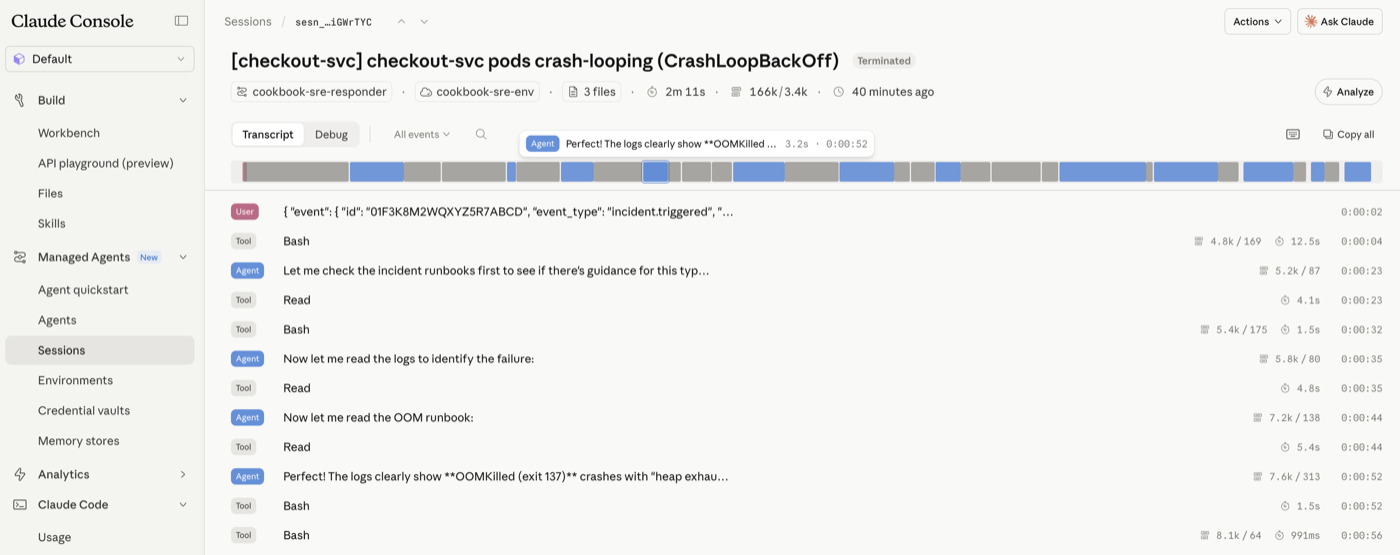

### Cleanup

Archive the session and the resources you created.


In [10]:
wait_for_idle_status(client, session_id)
client.beta.sessions.archive(session_id)
client.beta.environments.archive(env.id)
client.beta.agents.archive(agent.id)
client.beta.skills.versions.delete(skill.latest_version, skill_id=skill.id)
client.beta.skills.delete(skill.id)
print("archived")

archived


## Next steps: production wiring

Three swaps take this from notebook to on-call.

**Approve in Slack.** When `request_approval` arrives, post it to the
on-call channel with Block Kit buttons and send the
`user.custom_tool_result` back from the action handler. The
[`slack_data_bot` cookbook](slack_data_bot.ipynb) covers the Bolt app
setup; the approval-specific bit is small:

```python
def post_for_approval(session_id, event_id, summary):
    slack.client.chat_postMessage(
        channel=ONCALL_CHANNEL,
        text=summary,
        blocks=[
            {"type": "section", "text": {"type": "mrkdwn", "text": summary}},
            {"type": "actions", "elements": [
                {"type": "button", "text": {"type": "plain_text", "text": "Approve"},
                 "action_id": "approve", "value": f"{session_id}:{event_id}"},
                {"type": "button", "text": {"type": "plain_text", "text": "Reject"},
                 "action_id": "reject", "value": f"{session_id}:{event_id}"},
            ]},
        ],
    )

@slack.action("approve")
def on_approve(ack, body):
    ack()
    session_id, event_id = body["actions"][0]["value"].split(":")
    client.beta.sessions.events.send(
        session_id,
        events=[{"type": "user.custom_tool_result",
                 "custom_tool_use_id": event_id,
                 "content": [{"type": "text",
                              "text": json.dumps({"decision": "approved"})}]}],
    )
```

To drop the polling loop entirely, register a Console webhook on
`session.requires_action` — the platform calls your endpoint the
moment the agent pauses, and you post to Slack from there.

**GitHub instead of the mock.** Drop the `open_pull_request` /
`merge_pull_request` custom tools and give the agent the GitHub MCP
server instead, with the token stored in a vault so it never appears
in your code.
[`CMA_operate_in_production.ipynb`](CMA_operate_in_production.ipynb)
walks through per-user credentials.

```python
agent = client.beta.agents.create(
    ...,
    mcp_servers=[{"type": "url", "name": "github",
                  "url": "https://api.githubcopilot.com/mcp/"}],
    tools=[{"type": "agent_toolset_20260401", ...},
           {"type": "mcp_toolset", "server_name": "github"},
           {"type": "custom", "name": "request_approval", ...}],
)
session = client.beta.sessions.create(..., vault_ids=[github_vault.id])
```

**Live logs instead of a fixture.** Pass `DD_API_KEY` / `DD_APP_KEY`
through the environment config and let the agent `curl` the Datadog
Logs API from `bash` instead of reading a mounted file.

> See also the [Agent SDK site-reliability
> agent](https://github.com/anthropics/claude-cookbooks/blob/main/claude_agent_sdk/03_The_site_reliability_agent.ipynb)
> for the same problem solved with the local Agent SDK instead of the
> hosted Managed Agents runtime.


## What you learned

- Trigger a session from any external event — one API call from a
  PagerDuty webhook started the whole run.
- Attach a **Skill** to give the agent your team's conventions.
- Mount data with **resources**: `github_repository` for code, `file`
  for logs and runbooks.
- Use **custom tools** to call back into your app and gate actions on
  human approval via `requires_action`.
- Get the full audit trail for free in the **Console** session view.

Swap the mocks for GitHub MCP, a Slack approval button, and live
logs, and it's ready for on-call.
